# Synthetic 2D benchmarks

Moons, circles, varying-density blobs, annulus+outliers


In [1]:
from pathlib import Path                                                                                                                                                                                            
    
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs, make_circles, make_moons
                                                                                                                                                                                                                    
from mpc.filtration_builder import FiltrationBuilder
from mpc.pipeline import evaluate_all, run_bifiltration, run_standard_baselines                                                                                                                                     
                                                                                                                                                                                                                    
FIG = Path("figures")
FIG.mkdir(exist_ok=True)

In [ ]:
def annulus_with_outliers(n_ring=200, n_out=30, seed=42):
    rng = np.random.RandomState(seed)
    a = rng.uniform(0, 2 * np.pi, n_ring)
    r = 3.0 + 0.3 * rng.randn(n_ring)
    ring = np.column_stack([r * np.cos(a), r * np.sin(a)])
    out = 0.8 * rng.randn(n_out, 2)
    X = np.vstack([ring, out])
    y = np.r_[np.zeros(n_ring, int), np.ones(n_out, int)]
    return X, y

def varying_density_blobs(seed=0):
    a, _ = make_blobs(n_samples=60, centers=[[0, 0]], cluster_std=0.2, random_state=seed)
    b, _ = make_blobs(n_samples=60, centers=[[3, 0]], cluster_std=0.8, random_state=seed + 1)
    return np.vstack([a, b]), np.r_[np.zeros(60, int), np.ones(60, int)]

DATASETS = {
    "Moons": (*make_moons(200, noise=0.05, random_state=0), 2, 0.18),
    "Circles": (*make_circles(200, factor=0.5, noise=0.05, random_state=0), 2, 0.18),
    "Blobs (varying s)": (*varying_density_blobs(), 2, 0.30),
    "Annulus+outliers": (*annulus_with_outliers(), 2, 0.60),
}


In [5]:
results = {}
for name, (X, y, k, bw) in DATASETS.items():
    fb = FiltrationBuilder(X)
    f1 = fb.get_filtration_from_scipy_dist("euclidean")
    f2 = fb.get_filtration_from_density("gaussian", bw)
    labels = run_standard_baselines(X, k)
    for method in ("simplify", "persistence"):
        labels[f"Ours ({method})"] = run_bifiltration(
            X, f1, f2, n_clusters=k, method=method,
        ).labels_combined
    results[name] = (X, y, labels)

/Users/kiruxalight/diploma/new_diploma_2/venv/lib/python3.13/site-packages/sklearn/manifold/_spectral_embedding.py:328: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(
/Users/kiruxalight/diploma/new_diploma_2/venv/lib/python3.13/site-packages/sklearn/manifold/_spectral_embedding.py:328: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


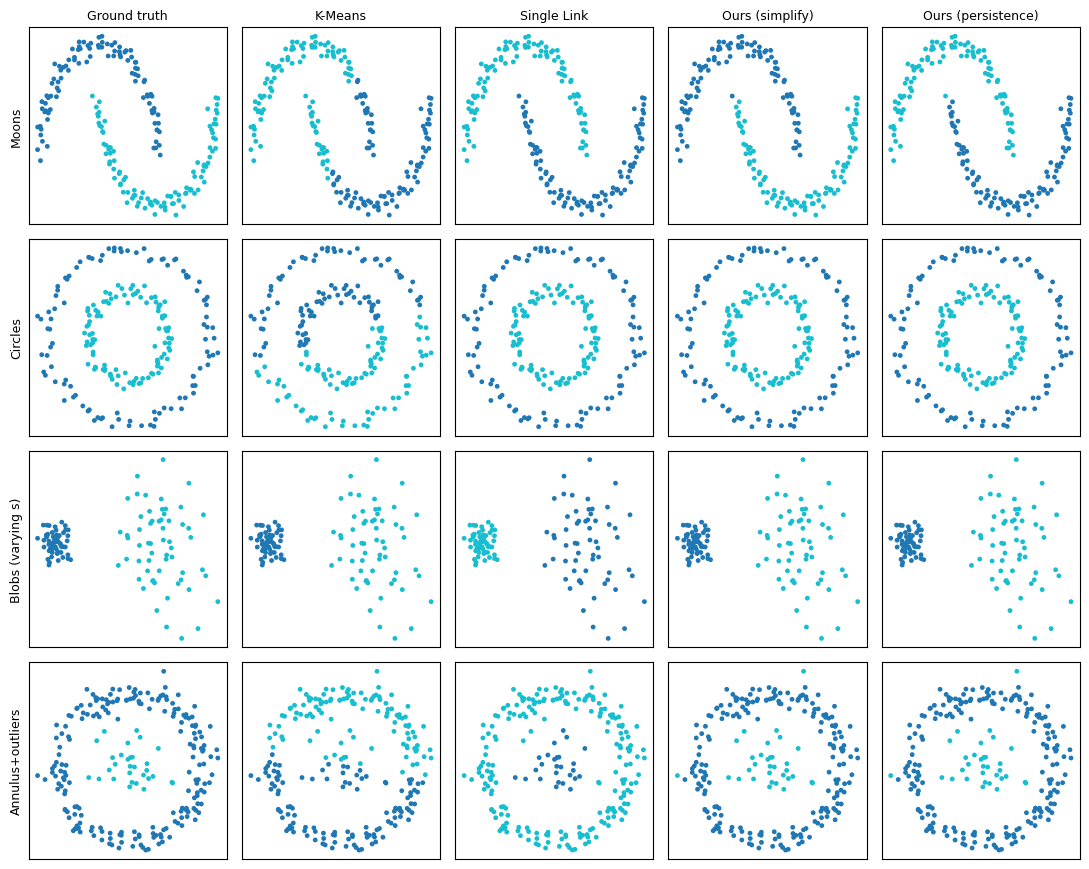

In [6]:
shown = ["Ground truth", "K-Means", "Single Link", "Ours (simplify)", "Ours (persistence)"]
fig, axes = plt.subplots(len(results), len(shown),
                         figsize=(2.2 * len(shown), 2.2 * len(results)))
for row, (name, (X, y, labels)) in enumerate(results.items()):
    for col, m in enumerate(shown):
        ax = axes[row, col]
        c = y if m == "Ground truth" else labels[m]
        ax.scatter(X[:, 0], X[:, 1], c=c, cmap="tab10", s=6)
        ax.set_xticks([]); ax.set_yticks([])
        if row == 0:
            ax.set_title(m, fontsize=9)
        if col == 0:
            ax.set_ylabel(name, fontsize=9)
fig.tight_layout()
fig.savefig(FIG / "synth2d_grid.png", dpi=150, bbox_inches="tight")
plt.show()